<h1><center>Data science for Geographers</center></h1>

<h2><center>Practical 1 - Data cleaning and organising using Python</center></h2>

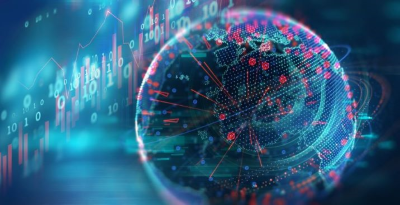

## Contents<a class="anchor" id="contents"></a>

- 1. [Introduction](#section1)
    - [The research question](#section1.1)
    - [A note about our data](#section1.1b)
    - [Data files](#section1.2)
    - [The problem...](#section1.3)
- 2. [A quick Python refresher](#sectionpy)
- 3. [Importing packages in Python](#section2)
    - [pandas](#section2.1)
- 4. [Reading our data](#section3)
    - [Reading files with `pd.read_csv()`](#section3.1)
    - [More on delimiters](#section3.2)
    - [Tools for examining our data](#section3.3)
    - [Sorting our data with `sort_values()`](#section3.4)
    - [Exercise](#exercise3)
- 5. [Data cleaning](#section4)
    - [Selecting variables (columns)](#section4.1)
    - [Removing observations (rows) with Boolean masks](#section4.2)
    - [Renaming variables with `rename()`](#section4.3)
    - [Exercise](#exercise4)
- 6. [Data merging](#section5)
    - [Introduction](#section5.1)
    - [Data keys for matching and merging data files](#section5.2)
    - [Step 1: Checking variables are unique with `drop_duplicates()`](#section5.3)
    - [Step 2: Bringing tables together with `merge()`](#section5.4)
    - [Step 3: Aggregating data with `groupby()`](#section5.5)
    - [Step 4: Merging all of the remaining tables](#section5.6)
    - [Exercise](#exercise5)
- 7. [Variable recoding](#section6)
    - [Missing data](#section6.1)
    - [Recoding variables](#section6.2)
    - [Labelling variables](#section6.3)
    - [Exercise](#section6.4)
- 8. [Writing our new dataset to a file](#section7)
- 9. [Conclusion](#section8)

## 1. Introduction <a class="anchor" id="section1"></a>

Welcome to the practical exercises for Data Science for Geographers! Starting with this practical, we are going to work through all of the steps required for a research project based on quantitative data. As well as this, at the end of each practical independent exercises are provided to test your knowledge of what you have learned. In this first practical we are going to be looking at the process of managing and cleaning data so that it is ready for analysis. This is an often neglected and under-appreciated part of the research process but it is also a crucial part of a successful analysis.

<b>NOTE: This is the Python version of this practical. There is also an R version in the same folder. Both versions do exactly the same things with the same data, so choose whichever language you are more comfortable with (you don't need to do both!).</b>

### The research question<a class="anchor" id="section1.1"></a>

Throughout these practicals, we are going to be completing a research project where we are interested in finding out if there is a relationship between the area-level availability of tobacco products and area-level measures of health. This is currently a hot topic in public health as policy-makers are looking for new ways to reduce population smoking. Showing that the volume of retailers in local neighbourhoods is associated with smoking rates is important as it provides policy-makers with the evidence they require to implement policy that targets tobacco retailing licenses. Our analysis will be very similar to this one:

https://tobaccocontrol.bmj.com/content/tobaccocontrol/25/1/75.full.pdf

The only difference being that we will be using area-level data (i.e. data about geographical areas) rather than individual level data (i.e. data about individual people or units). The areas that we are going to focus on are known as "datazones". These are the smallest geographical units at which data will be released to the public in Scotland. Datazones are groups of 2011 Census output areas which have populations of around 500 to 1,000 residents. There are 6,976 2011 Data Zones in Scotland. You can have a look at these in more detail here:

https://simd.scot/#/simd2020/BTTTFTT/9/-4.0000/55.9000/

### A note about our data<a class="anchor" id="section1.1b"></a>

In previous years we used the real versions of all of the datasets described below. The trouble with real data is that it is messy in ways that are not always helpful when you are learning (!) and in our case some of the relationships we want to explore in later practicals were quite hard to see. So this year, all of the data files we are using are <b>simulated</b>. In other words, I have created them using a computer program so that they look and behave like the real files (same file names, same variables, same quirks) but every datazone, postcode, retailer and value in them is made up.

Our simulated version of Scotland has 1,600 datazones rather than the real 6,976, and they have codes like `DZ00001` rather than the real `S01...` codes. The postcodes, council areas and place names are all fictional too. <b>So keep in mind that the results you get in these practicals tell us nothing about real tobacco retailing in Scotland!</b> But the skills are exactly the same and when you come to your own projects you will be doing all of this with real data.

### Data files<a class="anchor" id="section1.2"></a>

We have been given five different data files that we need to work with and process, each containing different pieces of information for these datazones.

#### TobaccoRegister.csv
The first thing we need is an "exposure" variable i.e. the thing we think will be associated with smoking behaviour, in this case the numbers of tobacco retailers in each area. In the real world, the Scottish Government has this information recorded in the Scottish Register of Tobacco and Nicotine Vapour Product Retailers. You can view it here:

https://www.tobaccoregisterscotland.org/search-the-register/?Name=&Postcode=&LocalAuthority=&BusinessType=&ProductType=&PremisesStatus=

The website is basically an archive list of all the tobacco retailers in Scotland and includes information on the name of the retailer, the address and postcode and whether it is currently active. Some of you may remember back to fundamental methods in geography, when you were doing a GIS practical... one of the datasets you were using in that practical came from the information contained in this website. Our (simulated) version of this data is in a file called: `TobaccoRegister.csv`

Unfortunately for us, this file does not contain a datazone variable so we will need to get this from somewhere else...

<b>NOTE! You may notice looking at the website that the real data is not available to download as a spreadsheet. It is only available statically on the webpage. To get the real data I used a process known as "web-scraping" using the python programming language (our simulated file has exactly the same layout as the one I scraped). Web scraping can be a very useful method of data collection and is used to obtain data or information from web-pages. This can be anything including numerical information (as is the case here) or textual information (including things like newspaper articles, reports and even forum and comment section posts). I have created some additional jupyter notebooks that cover this and other skills in Python. You can see these in the "Extras" folder. We won't be covering this in the class but if you are interested in learning more take a look!</b>

#### ScottishPostcodes.csv
This file is what we call a look-up file. It is so called because we use it to "look-up" other information. In this case it contains all of the postcodes in our (simulated) Scotland along with corresponding codes for the datazone that the postcode falls within. We will use this to connect our tobacco data (which only has postcodes) to datazones. The real version of this data comes from here: https://www.nrscotland.gov.uk/statistics-and-data/geography/our-products/scottish-postcode-directory/2020-2

#### simd2020.csv
This data contains all of the variables from the Scottish Index of Multiple Deprivation (SIMD). The SIMD contains lots of information at the datazone level including levels of health, unemployment, crime and others in each datazone. It also contains information about things like the total population in each datazone. This dataset will be used to add background information about the datazones to our analysis. The importance of this information (plus the urban and rural information below) will become clear later in our analysis!

#### urban_rural.csv
This dataset contains some additional useful information about the datazones; whether they are urban or rural or not. The real version of this dataset came from here: https://www2.gov.scot/Publications/2018/03/6040/downloads

#### smoking-at-booking.csv
This dataset contains smoking rates among pregnant women per datazone for different years (2012-2014, 2013-2015 etc). This dataset will provide our "outcome" data. This is the only population-scale dataset on smoking behaviours that is available (the other sources we might use are social surveys and based on a sample). The real version of this data came from here (note it may take a while to load): https://statistics.gov.scot/resource?uri=http%3A%2F%2Fstatistics.gov.scot%2Fdata%2Fsmoking-at-booking

### The problem...<a class="anchor" id="section1.3"></a>

The main problem with what we want to do is that datazones are larger than individual postcodes so we have to do some manipulation to our data to format it in the way that we want. When we have completed this practical, we will have a dataset which will consist of an observation (or row) per datazone (so 1,600 rows in our simulated data) with each row having a number of variables e.g. tobacco retailers, smoking rate, level of deprivation etc. Something like this...

| datazone | retailer_count | total_population | simd_decile | simd_rank | simd_quintile | income_rank | health_rank | smoking_rate | ... |
|---|---|---|---|---|---|---|---|---|---|
| DZ00005 | 1 | 865 | 8 | 1143 | 4 | 1391 | 1276 | 8.7 | ... |
| DZ00006 | 1 | 614 | 2 | 204 | 1 | 261 | 334 | 14.81 | ... |
| DZ00007 | 2 | 784 | 2 | 233 | 1 | 198 | 240 | 27.78 | ... |
| DZ00008 | 1 | 858 | 5 | 779 | 3 | 973 | 613 | 24 | ... |
| DZ00014 | 3 | 913 | 2 | 314 | 1 | 376 | 329 | 19.51 | ... |
| DZ00018 | 2 | 718 | 1 | 37 | 1 | 40 | 59 | 21.74 | ... |

#### [Go back to table of contents](#contents)

## 2. A quick Python refresher <a class="anchor" id="sectionpy"></a>

I am assuming that if you are using the Python version of this practical you have done a bit of Python before. But before we get stuck in, let's have a very quick refresher of the Python basics that we are going to rely on today. If any of this is new to you, have a look at the notebooks in the "Extras" folder (particularly Exercises 1 and 2) or come and ask us!

First, comments. Anything after a `#` symbol is a <b>comment</b>, in other words text in our code that is ignored by Python but is used to document and annotate our code. It is good practice to make heavy use of comments so when you come back to your code you can remember what it was doing!

Next, <b>variables</b>. In Python we store things in variables using the `=` sign. The name goes on the left and the value on the right...

In [ ]:
#Store a number and a string in two variables
population = 894
datazone = "DZ00005"

#Print them out
print(datazone, population)

Python has a few basic types of data that we will see a lot of today: <b>integers</b> (whole numbers like `894`), <b>floats</b> (numbers with a decimal point like `9.09`), <b>strings</b> (text, always inside quote marks like `"DZ00005"`) and <b>Booleans</b> (either `True` or `False`). We can check the type of anything using `type()`...

In [ ]:
type(population), type(9.09), type(datazone), type(True)

Booleans are really useful because we get them whenever we ask Python a question. Note the double equals sign `==` which means "is this equal to?" (a single `=` is for storing things in variables)...

In [ ]:
#Is our datazone code equal to "DZ00005"?
datazone == "DZ00005"

A handy trick that we will use later on: Python treats `True` as 1 and `False` as 0. So if we add up a set of Booleans, we get a count of how many of them are `True`...

In [ ]:
sum([True, False, True, True])

That last bit of code used a <b>list</b>, which is a collection of things inside square brackets `[ ]`. We will use lists a lot today to give Python lists of column names. The other collection we will need is a <b>dictionary</b>, which is a set of `key: value` pairs inside curly brackets `{ }`. We will use these when we want to tell Python to change one thing into another (e.g. an old column name into a new one)...

In [ ]:
#A list of column names
columns = ["datazone", "total_population", "simd_rank"]

#A dictionary matching old names to new names
new_names = {"Data_Zone": "datazone", "Total_population": "total_population"}

#We get things out of a list by position (starting at 0!) and out of a dictionary by key
columns[0], new_names["Data_Zone"]

Finally, <b>functions</b> and <b>methods</b>. A function does something to whatever we put in its brackets, like `sum()` and `type()` above. A method is a function that belongs to a particular object and is called with a dot after the object's name. For example, strings have an `upper()` method...

In [ ]:
datazone.lower()

You will see a lot of these dots today because most of the things we do to our data in pandas are methods (e.g. `simd.head()`). That's all we need to get going!

#### [Go back to table of contents](#contents)

## 3. Importing packages in Python <a class="anchor" id="section2"></a>

### pandas<a class="anchor" id="section2.1"></a>
Python on its own doesn't know much about working with tables of data. Like R, it relies on lots of different add-on packages (or libraries) that extend the functionality of the core language in lots of useful and helpful ways. In order to complete the exercises, we'll need to import some of these. We do this using the `import` command.

The package we are going to use today is called `pandas`. pandas is by far the most widely used package for working with tables of data in Python and it is what most data scientists use for exactly the kinds of tasks we are doing today. Tables of data in pandas are called <b>DataFrames</b>. More info on pandas here: https://pandas.pydata.org/docs/

Much of what we are going to be doing is written up in the book "Python for Data Analysis" by Wes McKinney (who created pandas), which is very helpfully freely available online here: https://wesmckinney.com/book/

It is definitely worth referring to as you learn these techniques! The "10 minutes to pandas" guide is also a really good quick reference: https://pandas.pydata.org/docs/user_guide/10min.html. And if you have used R before, there is a handy page comparing R and pandas commands side by side: https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_r.html

These links will be a really useful reference for you as you learn these techniques. I would recommend bookmarking them in your web browser for easy access!

So let's go ahead and import pandas. Note the `as pd` part. This gives pandas a short nickname so that we can type `pd.` instead of `pandas.` every time we use it. Everybody uses `pd` so you will see this in almost all pandas code you come across.

In [ ]:
#Import the pandas package, with the nickname pd
import pandas as pd

#### [Go back to table of contents](#contents)

## 4. Reading our data <a class="anchor" id="section3"></a>

### Reading files with pd.read_csv()<a class="anchor" id="section3.1"></a>
The first task we have is to read in all of our datasets into memory so we can access them and work with them. Let's start by making sure Python knows where to look for our files.

Python always has what is called a <b>working directory</b>. This is the folder that Python looks in when we ask it to open a file. When you open a notebook, the working directory is automatically set to the folder that the notebook is saved in. All of the data files for this week are in the same folder as this notebook, so Python should already be looking in the right place. We can check where Python is looking using `os.getcwd()` (short for "get current working directory") from the built-in `os` package...

If you are working on your own computer, or your files are stored somewhere else, you can point Python at a different folder using `os.chdir()` ("change directory"), e.g. something like:

`os.chdir("C:/Users/yourname/Documents/dissertation")`

For these practical sessions I would recommend copying all of the materials for each week (in this case the datafiles and the notebook itself) into a new folder called e.g. `week2` in your files area. That way you can go back to the original versions of the files if you need to (if something goes wrong). As long as the notebook and the data files are in the same folder, everything below will work without any changes.

HINT: If you need help with copying your files please ask!

In [ ]:
#Check which folder Python is looking in
import os
os.getcwd()

We can check we are in the right place by using the command `os.listdir()` which will list all of the files in the current working directory, as below...

In [ ]:
os.listdir()

Now we need to tell Python to read in the datafiles into different DataFrames so we can work with them. We do this using the `read_csv()` function from pandas as below...

In [ ]:
simd = pd.read_csv('simd2020.csv')

There are a couple of things to note about this code. The first is the `=` sign, which as we saw above is how we store things in Python. For example `smoking = pd.read_csv('smoking-at-booking.csv')` applies the function `read_csv` to the filename `smoking-at-booking.csv` and puts the result into a DataFrame called `smoking`. The second is the `pd.` at the start. This tells Python that `read_csv()` is a function from the pandas package (remember `pd` is our nickname for pandas).
<b>This is a key concept... whenever we use a pandas function we need to put `pd.` in front of it.</b>

### More on delimiters<a class="anchor" id="section3.2"></a>
You might be wondering what "CSV" means in the filename extension? This is quite an important concept so i'll explain it here. "CSV" stands for "comma separated values" and is a data file type that is universal and can be imported by almost any statistical software, including Python. If you were to open a csv file in a notepad program, you would see something like this:

`name,surname,age,postcode
joe,bloggs,21,EH89XY`

As you can see, the first row is the column names and the second row is the values of each variable. As you can see, each individual piece of information in the file is <i>separated</i> by a symbol, in this case a comma. When importing files, the statistical software will look for these symbols and know to put the data into a separate cell.

It is also possible, to use a different symbol if you need to. In our case all of our files are delimited by a `,` apart from our `TobaccoRegister.csv` data which cannot use a `,` and instead uses the `|` symbol.

<b>Bonus point question: Can you think of a reason why we can't use a comma to delimit the tobacco register data?</b>

When not using a comma to delimit our data, we need to tell `read_csv()` which delimiter we are using with the `sep=` argument (short for "separator").

In [ ]:
tobaccoregister = pd.read_csv('TobaccoRegister.csv', sep="|")

In [ ]:
tobaccoregister.head()

Note the `, sep="|"` part which specifies the correct symbol. What this shows is that we need to be aware of the format of our data and the symbol that is used to separate the values.

Note as well that in a notebook, only the <b>last</b> line of a code cell is displayed automatically. If we want to see more than one thing from the same cell we can use `print()` or, as we do below, just put them in separate cells.

In [ ]:
tobaccoregister.shape

### Tools for examining our data<a class="anchor" id="section3.3"></a>
Now we have our data imported into Python we can have a look at it with some useful commands.

The first of these is `.shape` which gives us the `dimensions` of our datasets. Note that `.shape` doesn't have any brackets after it. This is because it is not a method that <i>does</i> something, it is just a piece of information stored with the DataFrame (called an <b>attribute</b>)...

In [ ]:
simd.shape

You can see that the number of observations (rows) is on the left and the number of columns is the number on the right. You can see the datasets that relate to `datazones` as they each have `1600` observations.

Another useful tool is the `head()` method, which allows us to examine the top 5 rows of data and column names...

In [ ]:
#Examine the first few rows of each datafile
simd.head()

we can also specify how many rows we want by putting a number in the brackets...

In [ ]:
simd.head(30)

This command is useful but if the number of columns is large it will cut off some of the columns (you will see a `...` in the middle of the table).

Instead, to list all of the column names we can use `.columns`...

In [ ]:
#Look at the column headers for each file
simd.columns

Now we can see that we have a lot of variables, many of them terribly named and many that we do not need. Our next task is to clean all of this up to make it easier to work with.

Before we do however, one last useful tool is the `sort_values()` method which we can use to sort our data.

### Sorting our data with sort_values()<a class="anchor" id="section3.4"></a>

To do this we take the DataFrame we want to sort and then give `sort_values()` the variable we wish to sort by. So below we sort our `simd` dataset according to the `Total_population` variable...

In [ ]:
simd.sort_values('Total_population')

We can also do this in descending order by adding `ascending=False`...

In [ ]:
simd.sort_values('Total_population', ascending=False)

And we can sort by multiple variables (i.e. sort within other variables...) by giving `sort_values()` a list of variables.

In [ ]:
simd.sort_values(['SIMD2020v2_Decile', 'Total_population'])

### Exercises<a class="anchor" id="exercise3"></a>

1. Read the remaining datasets (`"smoking-at-booking.csv", "urban_rural.csv" and "ScottishPostcodes.csv"`) into DataFrames using `pd.read_csv()`. Use the names `smoking`, `postcodes` and `urban_rural` to name these based on the contents of the file.
2. Look at the dimensions, the first few rows and the column names of the DataFrames that you just created.

Enter your answers into the empty code cell below. Once you have had a go at this, you can see the solutions in the cell underneath it. The code in this cell is hidden, so all you will see is a thin bar or three dots (`...`). Click on this to reveal the code, and click on the blue bar to the left of the cell to hide it again.

<b>NOTE: Make sure you run the solutions cell (even if you are happy with your own answer) before moving on. The code later in the practical relies on it!</b>

In [ ]:
#Answers
#Part 1
postcodes = pd.read_csv('ScottishPostcodes.csv')
urban_rural = pd.read_csv('urban_rural.csv')
smoking = pd.read_csv('smoking-at-booking.csv')

#Part 2 (we use print() so that we can see everything from one cell)
print(postcodes.shape)
print(urban_rural.shape)
print(smoking.shape)

print(postcodes.head())
print(urban_rural.head())
print(smoking.head())

print(postcodes.columns)
print(urban_rural.columns)
print(smoking.columns)

#### [Go back to table of contents](#contents)

## 5. Data cleaning <a class="anchor" id="section4"></a>

### Selecting variables (columns)<a class="anchor" id="section4.1"></a>
The first stage of our data cleaning is to remove excess variables that we dont need. this is often the first thing we do because it makes our datafiles much easier to manage and less cumbersome. If you are using big secondary data sources for your project these may have huge numbers of variables which you dont need so this will be very useful.

We do this by giving our DataFrame a list of the variables we want to keep inside square brackets. Let's start with the `smoking` dataset. Remember this contains smoking rates among pregnant women for all of the datazones in scotland for different years. For our analysis we are only interested in the latest years data which is 2017-2019. So our first task is to remove all of the other variables (apart from the datazone).

The code for this is pretty straightforward. We start with the name of the dataset `smoking`, followed by a list of the variables we want to keep. Notice the <b>double</b> square brackets. The outer brackets say "select some columns" and the inner brackets are the list of column names. We then reassign this new DataFrame, in this case to the same name `smoking`. <b>NOTE: this overwrites and replaces the previous DataFrame which is fine for the exercise but you may want to create a new one when you do this for real, otherwise you would need to re-import the data if you make a mistake.</b>

In [ ]:
smoking.head()

In [ ]:
#Trim smoking file
smoking = smoking[['datazone', '17_19']]
smoking.head()

Note that in pandas all of our column names are strings, so they always need quote marks around them. <b>If you are unsure what a string is, have another look at the Python refresher above or come and ask us!</b>

Let's do the same with the `postcodes` file. We only need the `Postcode, DataZone2011Code, DateOfIntroduction, DateOfDeletion` variables from this file.

In [ ]:
postcodes.head()

In [ ]:
#Remove variables we dont need from the postcode file
postcodes = postcodes[['Postcode', 'DataZone2011Code', 'DateOfIntroduction', 'DateOfDeletion']]
postcodes.head()

We need to remove other variables from other datasets but I want to use these remaining datasets to show how we can chain several steps together a bit later on so will leave these for now.

### Removing observations (rows) with Boolean masks<a class="anchor" id="section4.2"></a>
As well as removing `variables` (columns) that we dont need we can also remove observations that are not needed. A good example of this is the postcodes file because it contains records of postcodes that are no longer in active use. These postcodes are not of use to us because they wont be matched to a tobacco retailer postcode. We can filter these observations by using the `DateOfIntroduction` and `DateOfDeletion` variables. Let's look at these variables.

Note how we can do two things at once in the code below. We first select just the two variables `DateOfIntroduction` and `DateOfDeletion`, and then call `.head(100)` on the result to display only the first 100 rows. This is called <b>method chaining</b>. We will see this more clearly later in the practical but for now it is enough to say that this is one of the most useful and helpful features of pandas!

In [ ]:
postcodes[['DateOfIntroduction', 'DateOfDeletion']].head(100)

You can see that some of the postcodes have a date in the `DateOfDeletion` column. These postcodes are the ones that have been deleted and so we can remove them. The other ones have a `NaN` ("not a number") which is how pandas shows that the value is missing (because they are still in use). We can filter on this variable to remove the deleted postcodes...

In [ ]:
postcodes = postcodes[postcodes['DateOfDeletion'].isna()]

#Display the new postcodes file
postcodes[['DateOfIntroduction', 'DateOfDeletion']].head(100)

Let's work through how this works. `postcodes['DateOfDeletion'].isna()` asks the question "is `DateOfDeletion` missing?" for every row, and gives us back a `True` or `False` for each one. This set of `True`s and `False`s is called a <b>Boolean mask</b>. When we put a Boolean mask inside the square brackets after our DataFrame (`postcodes[...]`) pandas keeps the rows that are `True` (i.e. the ones where `DateOfDeletion` is missing) and removes everything else.

We can of course also filter based on the value of a variable. A good example of this is filtering out the tobacco retailers that are "inactive". We wont be needing these records in our analysis. Lets take a look at the `tobaccoregister` data again to remind ourselves:

In [ ]:
tobaccoregister.head()

You can see that some of the retailers have "Inactive" in the `Status` column. We want to remove these and we can do that below. Note that because the value of the status variable is a string we need to use quote marks around `Active`. If it was just a number we wouldnt need the quote marks. Note as well the <b>double</b> equals sign `==` which, remember, asks the question "is this equal to?".

In [ ]:
tobaccoregister = tobaccoregister[tobaccoregister['Status'] == "Active"]

tobaccoregister.head(100)

### Renaming variables with rename()<a class="anchor" id="section4.3"></a>
As well as removing observations and variables, we may also want to rename some of the variables. Some of our data files have really clunky and cumbersome names which are difficult to manage. We can change this with the `rename()` method.

To do this, we give `rename()` a dictionary (remember those?) of the old names and the new names using `columns=`.

Let's look at the smoking file and look at how to change the name of the variable `17_19` to `smoking_rate`...

In [ ]:
smoking.head()

In [ ]:
smoking = smoking.rename(columns={'17_19': 'smoking_rate'})
smoking.head()

The key thing to remember here is that the old variable name comes first, then the `:` and then the new name. (If you have used R before, be careful, as this is the opposite way round to R's `rename()`!)

Let's do the same with renaming variables in the `postcodes` file, only this time let's take advantage of the fact that we can change multiple variables at once. It is always good practice to name your variables in lowercase letters so we'll change `Postcode` to `postcode` and also rename the dates of deletion and introduction as well.

We can do this by just adding more pairs to our dictionary, separated with a comma. Note when we do this it makes the line of code very long so pressing enter after the comma breaks the code into multiple lines to make it easier to read, but the functioning of the code remains unchanged.

In [ ]:
#Rename postcode field
postcodes = postcodes.rename(columns={'Postcode': 'postcode',
                                      'DateOfIntroduction': 'date_introduced',
                                      'DateOfDeletion': 'date_deleted'})

postcodes.head()

Now let's do the same with the `simd` data which is more complicated. Let's remind ourselves of the columns in the `simd` data:

In [ ]:
simd.columns

As you can see there are a lot of variables here many with cumbersome and long names and many that we dont actually need. Wouldnt it be great to be able to do all of these tasks (renaming and selecting variables) in one command? This is a really good opportunity to demonstrate why method chaining is so useful...

What we are going to do here is take the output from our `rename()` method and pass it straight on to select only the variables that we have renamed. In other words we are going to chain together multiple steps into one command using the code below. Let's run it, see what it does and then we'll discuss it in more detail below...

In [ ]:
#rename the variables in the simd file
simd = (
    simd
    .rename(columns={'Data_Zone': 'datazone',
                     'Total_population': 'total_population',
                     'SIMD2020v2_Decile': 'simd_decile',
                     'SIMD2020v2_Rank': 'simd_rank',
                     'SIMD2020v2_Quintile': 'simd_quintile',
                     'SIMD2020v2_Income_Domain_Rank': 'income_rank',
                     'SIMD2020_Health_Domain_Rank': 'health_rank',
                     'SIMD2020_Employment_Domain_Rank': 'employment_rank',
                     'SIMD2020_Education_Domain_Rank': 'education_rank',
                     'SIMD2020_Access_Domain_Rank': 'access_rank',
                     'SIMD2020_Crime_Domain_Rank': 'crime_rank',
                     'SIMD2020_Housing_Domain_Rank': 'housing_rank',
                     'ALCOHOL': 'alcohol_admissions',
                     'DRUG': 'drug_admissions'})
    [['datazone', 'total_population', 'simd_decile', 'simd_rank', 'simd_quintile', 'income_rank', 'health_rank',
      'employment_rank', 'education_rank', 'access_rank', 'crime_rank', 'housing_rank', 'alcohol_admissions',
      'drug_admissions']]
)

#Display this new data
simd.head(20)

Let's work through how this has worked...

We start with our `simd` DataFrame. We then call `.rename()` on it to rename all of our variables, all the way to `drug_admissions`. `.rename()` gives us back a new DataFrame, and so we can immediately put our list of columns in square brackets straight after it to keep only the variables specified. The key here is that at no point do we need to save the intermediate, renamed-but-not-yet-selected DataFrame. Each step just passes its output on to the next one. The round brackets `( )` around the whole thing are there so that we can spread the chain over several lines to make it easier to read. This is a really powerful feature of pandas because it allows us to easily "chain" together multiple and complex steps into one command. In other words we can do this with almost any combination of methods.

Of course, you dont need to do this. You could just rename the variables in one command and then select the variables in a separate command but the above is neater and easier to read once you get used to it.

Looking at the output, we can now see that we have completely re-worked our `simd` datafile into a much clearer and cleaner dataset.

### Exercises<a class="anchor" id="exercise4"></a>

1. Select only the variables `Datazone2011` and `UR6_2013_2014` from the urban_rural dataset.
2. Rename the `Datazone2011` variable in the urban_rural file to `datazone` and the `UR6_2013_2014` variable to `urban_rural`.

As before, the solutions are hidden in the cell below the empty code cell. Remember to run the solutions cell before moving on.

In [ ]:
#Answers
urban_rural = (
    urban_rural[['Datazone2011', 'UR6_2013_2014']]
    .rename(columns={'Datazone2011': 'datazone',
                     'UR6_2013_2014': 'urban_rural'})
)

#Or you could do it this way as well:
#urban_rural = urban_rural[['Datazone2011', 'UR6_2013_2014']]
#urban_rural = urban_rural.rename(columns={'Datazone2011': 'datazone', 'UR6_2013_2014': 'urban_rural'})

#### [Go back to table of contents](#contents)

## 6. Data Manipulation <a class="anchor" id="section5"></a>

### Introduction<a class="anchor" id="section5.1"></a>
Now we are really getting into our data cleaning. We have tidied up each of the individual files and are now ready for the really important step of merging them all together and creating any new variables we need.

When doing data science type research, the situation we find ourselves in now (i.e. lots of different and separate tables) is very common. Collectively, multiple tables of data are called relational data because it is the relations (i.e. the data in different tables), not just the individual datasets, that are important. In order for us to do our analysis we need to begin to draw these tables together into one table. At the moment the various different tables have different combinations of datazone and postcode variables and we need to use these two bits of information to join them together. Remember we want the final data to look something like the table below where each datazone has a count of the total number of tobacco retailers (labelled `retailer_count`) and lots of other information about each datazone:

| datazone | retailer_count | total_population | simd_decile | simd_rank | simd_quintile | income_rank | health_rank | smoking_rate | ... |
|---|---|---|---|---|---|---|---|---|---|
| DZ00005 | 1 | 865 | 8 | 1143 | 4 | 1391 | 1276 | 8.7 | ... |
| DZ00006 | 1 | 614 | 2 | 204 | 1 | 261 | 334 | 14.81 | ... |
| DZ00007 | 2 | 784 | 2 | 233 | 1 | 198 | 240 | 27.78 | ... |
| DZ00008 | 1 | 858 | 5 | 779 | 3 | 973 | 613 | 24 | ... |
| DZ00014 | 3 | 913 | 2 | 314 | 1 | 376 | 329 | 19.51 | ... |
| DZ00018 | 2 | 718 | 1 | 37 | 1 | 40 | 59 | 21.74 | ... |

In order to do this we need to join datasets together. Before we get into this, we need to understand the concept of `keys`.

### Data keys for matching and merging data files <a class="anchor" id="section5.2"></a>

A `key` is used to connect a pair of tables and is a variable (or set of variables) that uniquely identifies an observation. In simple cases as we have here, a single variable is sufficient to identify an observation. For example, each postcode area in Scotland is uniquely identified by its postcode value and where postcode values appear in multiple datasets we can join them together (e.g. `QD37 5UP` in one dataset can be matched with `QD37 5UP` in another dataset). In some of the other tables, the `datazone` code is a unique `key`. In other words the datazone code `DZ00888` in one data table corresponds to the same `DZ00888` code in another table. We can use these `key` variables to link all of our data together into one file automatically!

However, the requirement for all of this to work is that the `key` variable needs to be unique in <b>at least one of the tables to be joined</b>. You can think through why this is...

It's because otherwise there is no way to know which of the two identical postcodes or datazones we should connect to. The visual illustration below may help you see this (source: Wickham 2017):

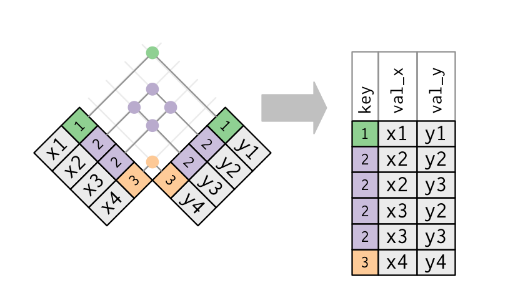

Hopefully this illustrates this a little more clearly. The image on the left shows two separate datafiles that we want to join. Each datafile has a variable that we want to join together (`x` in one dataset and `y` in the other). As you can see in the image on the right, joining these datasets together is difficult because the `keys` in each are not unique (in other words, each datafile has more than one `2` value, i.e. there are duplicates). We call this situation `duplicate keys`.

So, taking all of this into account, we need to do our matching process as follows:

1. Firstly, because our `tobaccoregister` table has no `datazone` code, we need to get it from another file which has both the datazone code AND a postcode value. We know that the `postcodes` table has both so if we join these two tables together using the `postcode` value we will get the `datazone` added to the tobacco retailer table. But before we do this, we need to check that postcode is indeed unique in the postcodes file to avoid a duplicate keys situation.

2. Once we remove duplicate keys, we can then connect the `tobaccoregister` table to the `postcodes` table.

3. We then need to `aggregate` (in other words summarise) the tobacco retailer table so that it shows the number of retailers in each datazone. In other words, we *collapse* the tobacco retailer table into a row per datazone with a new variable which includes counts of retailers in each datazone (you can see this in the second column in the table above).

4. We then join all of the other tables (`simd`, `smoking` and `urban_rural`) to this `aggregated` table based on the datazone code as the `key`.

So let's do this step by step...

### Step 1: Checking we have unique postcodes<a class="anchor" id="section5.3"></a>

We can use the `duplicated()` method to check if we have any duplicated observations. This method returns either `True` or `False` for each observation depending on whether it is a duplicate. Here we use it to test each observation in the variable `postcode` in the table `postcodes`. We take the output and put it in a new object called `dupes`. If we run the `sum()` method on this it will tell us how many of the items in the `dupes` object are true (remember Python counts each `True` as a 1 and each `False` as a 0).

In [ ]:
postcodes.head()

In [ ]:
dupes = postcodes['postcode'].duplicated()
print(dupes.sum())

When we run it we see there are 18 duplicated postcodes. Hmm. Let's take a look at them. We can use our `dupes` object as a Boolean mask to pick out just the duplicated rows...

In [ ]:
#Look at the duplicated postcodes
postcodes[dupes]

These are exact copies of records that are already in the file (this happens surprisingly often with real data too!). Why does this matter? Think back to the duplicate keys diagram above. If a postcode appears twice in our look-up table, then any tobacco retailer with that postcode will be matched twice when we join the tables, and so will be <b>counted twice</b> when we come to count the retailers in each datazone.

We can use the `drop_duplicates()` method to automatically remove these duplicates whilst keeping all of our variables. The `subset=` part tells pandas which variable to check for duplicates...

In [ ]:
postcodes = postcodes.drop_duplicates(subset='postcode')
postcodes.head()

And let's check that it has worked by counting the duplicates again. This time we should get a 0.

In [ ]:
print(postcodes['postcode'].duplicated().sum())

### Step 2: Bring datasets together with merge()<a class="anchor" id="section5.4"></a>

Now that we know `postcode` uniquely identifies observations in the `postcodes` table we can go ahead with step 2 which is linking the `tobaccoregister` table with the `postcodes` table. This will attach a `datazone` to our `tobaccoregister` table.

In pandas we join tables together using the `merge()` method. There are a few different types of join, which we choose using the `how=` argument, and it is worth knowing the difference because choosing the wrong one can cause some real problems:

- `x.merge(y, how='left')` keeps <b>all</b> of the rows in `x` and adds on the matching information from `y`
- `x.merge(y, how='right')` does the opposite, it keeps all of the rows in `y`
- `x.merge(y, how='inner')` keeps <b>only</b> the rows that match in both tables
- `x.merge(y, how='outer')` keeps all of the rows from both tables, whether they match or not

Here we want a left join. We want to keep every retailer and add a datazone to each one. What we <b>don't</b> want is to add in all of the postcodes that don't have a tobacco retailer (which is most of them!). If we used an outer join here we would end up with an extra row for every one of these postcodes and, when we come to count the rows in each datazone in Step 3, we would be counting postcodes and not tobacco retailers!

The syntax is actually pretty straightforward. We start with the table we are joining to (in this case `tobaccoregister`), then inside the brackets we specify the table that is being joined (in this case `postcodes`), the variable that we want to use as the `key` in both tables using `on=...` and finally the type of join using `how=...`.

In [ ]:
#Merge the tob register data with the postcode data
tobaccoregister = tobaccoregister.merge(postcodes, on='postcode', how='left')

tobaccoregister.head()

If you scroll to the right side of the new table above, you will see all of the variables from the `postcodes` table have now been added to the corresponding observation in the `tobaccoregister` table based on the matching postcode.

This is great, but one key thing to consider when merging tables in this way is that we should always check to see if any of the retailers *didn't* get matched (i.e. in this case any postcodes that couldn't be matched).

In R there is a handy function for this called `anti_join()`. pandas doesn't have one, but we can do exactly the same thing using the `isin()` method. `tobaccoregister['postcode'].isin(postcodes['postcode'])` asks "is this retailer's postcode in the postcodes table?" for every retailer. The `~` symbol in front of it means "not", so it flips all of the `True`s and `False`s round. Putting this Boolean mask in square brackets after `tobaccoregister` gives us a list of the observations in the `tobaccoregister` table that couldn't be matched to a postcode. This is useful to help us figure out why this is the case.

In [ ]:
#Find the retailers whose postcodes didnt match
anti_joined_file = tobaccoregister[~tobaccoregister['postcode'].isin(postcodes['postcode'])]

print(anti_joined_file.shape)
anti_joined_file.head()

Using `.shape` and `head()` on this new table we can see we have 228 unmatched cases. Why might this be? Let's go back to the original postcode file and look these postcodes up. Remember that we filtered out the postcodes that are no longer in use earlier on, so we need to read the file in again...

In [ ]:
#Look up the unmatched postcodes in the original postcode file
all_postcodes = pd.read_csv('ScottishPostcodes.csv')

all_postcodes[all_postcodes['Postcode'].isin(anti_joined_file['postcode'])][['Postcode', 'DateOfIntroduction', 'DateOfDeletion']]

You should see that most of the unmatched postcodes <b>are</b> in the original file but they have a date in the `DateOfDeletion` column. In other words, these retailers are registered at postcodes that are no longer in use. The remaining handful (compare the number of rows here with the 228 above) don't appear in the postcode file at all, most likely because of typos when the register was filled in. For a proper project we might attempt to fix this problem (e.g. by looking up each retailer's address to find their current postcode) but for the purposes of this exercise we will just ignore them.

Going back to our newly joined `tobaccoregister` data, we now need to remove these observations. If we run the below code we can see that all of these unmatched observations are still included.

In [ ]:
tobaccoregister[tobaccoregister['DataZone2011Code'].isna()][['Premises Name', 'DataZone2011Code']]

Lets remove these now and while we are at it let's also clean up other parts of the table including removing variables we dont need and renaming the remaining variables.

In [ ]:
tobaccoregister = (
    tobaccoregister[tobaccoregister['DataZone2011Code'].notna()]
    [['DataZone2011Code', 'postcode']]
    .rename(columns={'DataZone2011Code': 'datazone'})
)

tobaccoregister.head()

Now we have a really clean dataset to work with.

### Step 3: Aggregating data with groupby()<a class="anchor" id="section5.5"></a>
The retailers table now contains a row of data per retailer but we need to <b>aggregate</b> this so that it contains the total number of retailers per datazone. This is a very common task in data science, especially in geography where we often interested in area measures and characteristics.

The process to do this is very straightforward using the `groupby()` method. We use `groupby()` to identify groups (in this case by datazone) and then say what we want to calculate for each of these groups. In this case we want the `size()` of each group, in other words how many rows (retailers) are in each datazone.

`groupby()` gives us back the counts with the datazone codes as the row labels (pandas calls these the <b>index</b>) so we finish off with `reset_index()`, which turns the datazone codes back into a normal column and lets us give our new count column a name, `retailer_count`.

In [ ]:
#Now we need to aggregate by the count of premises
tobaccoregister = (
    tobaccoregister
    .groupby('datazone')
    .size()
    .reset_index(name='retailer_count')
)

tobaccoregister.head()

Now we can see that for each datazone, we have a <b>count</b> of the total numbers of retailers in each datazone.  

### Step 4: Merging all of the remaining files together<a class="anchor" id="section5.6"></a>

We now just need to merge all of the remaining files to our new `tobaccoregister` table, including the `simd`, `smoking` and `urban_rural` tables. For each of these, and as before, I also check for any unmatched cases.

This time we <b>do</b> want an outer join. We want to keep every datazone, including the ones that didn't appear in our retailer table.

In [ ]:
#Merge the aggregated tobacco data with the simd data
tobaccoregister = tobaccoregister.merge(simd, on='datazone', how='outer')

unmatched = tobaccoregister[~tobaccoregister['datazone'].isin(simd['datazone'])]

unmatched.head()

Before we go any further, let's look at what has happened to the datazones that don't have any tobacco retailers. Because we used an outer join, every datazone in the `simd` table has been kept, including those that didn't appear in our retailer counts at all. Let's look at them...

In [ ]:
#Datazones with no retailer count
print(tobaccoregister[tobaccoregister['retailer_count'].isna()][['datazone', 'retailer_count', 'total_population']])

#How many are there?
print(tobaccoregister['retailer_count'].isna().sum())

So 616 datazones have a `NaN` for `retailer_count`. But this is a bit misleading. We haven't actually got missing information here, we know exactly how many tobacco retailers these datazones have... none! They didn't appear in our retailer table simply because there were no retailers there to count. So these `NaN` values should really be zeros.

This matters a lot. Later on we are going to remove the missing data from our dataset and if we left these as `NaN` we would throw away all of the datazones with no tobacco retailers, which are exactly the datazones we need to compare against! We can fix this using the `fillna()` method.

There is one more small thing to do here. Because pandas can't store a `NaN` in a column of whole numbers, it quietly turned our `retailer_count` column into floats (numbers with decimal points) when we did the merge. Now that we've replaced the missing values we can turn it back into integers using `astype(int)`.

In [ ]:
#Datazones with no retailers have zero retailers, not missing data
tobaccoregister['retailer_count'] = tobaccoregister['retailer_count'].fillna(0).astype(int)

#Check there are no missing values left
print(tobaccoregister['retailer_count'].isna().sum())

Now let's add in the smoking data...

In [ ]:
#Merge this data with the pregnancy smoking data
tobaccoregister = tobaccoregister.merge(smoking, on='datazone', how='outer')

unmatched = tobaccoregister[~tobaccoregister['datazone'].isin(smoking['datazone'])]

unmatched.head()

### Exercise<a class="anchor" id="exercise5"></a>

1. Perform an outer join (`how='outer'`) between our joined `tobaccoregister` data and the last file - `urban_rural`.
2. Check this join by also checking for any unmatched observations. HINT for 1 and 2: look at the code above...
3. Check the whole dataset to make sure all of the new variables have been added. HINT remember `head()` and `.columns`

As before, the solutions are hidden in the cell below the empty code cell. Remember to run the solutions cell before moving on.

In [ ]:
#Answers
tobaccoregister = tobaccoregister.merge(urban_rural, on='datazone', how='outer')

unmatched = tobaccoregister[~tobaccoregister['datazone'].isin(urban_rural['datazone'])]

print(unmatched.head())

print(tobaccoregister.head())
print(tobaccoregister.columns)

#### [Go back to table of contents](#contents)

## 7. Variable recoding <a class="anchor" id="section6"></a>

### Missing data<a class="anchor" id="section6.1"></a>

Sometimes, data is missing for a variety of reasons. You may have seen some missing information when looking at the datafiles. Missing data is quite problematic for lots of reasons and we will discuss this in more detail later in the course. For now, we just need to know how to remove missing data as part of our data cleaning process. <b>NOTE! Simply removing missing data is not always recommended without some understanding of WHY the data is missing in the first place. Doing so can cause issues with our analysis and particularly our interpretation. We will explain why later on in the course but perhaps have a think now about why this might be!</b>

The code below removes all rows that have any missing values from our data...

In [ ]:
#Remove all missing data
tobaccoregister = tobaccoregister.dropna()

This is nice and simple in pandas, `dropna()` just removes every row which has a missing value in any of the variables. For now we just need to remove the missing cases in the dataset so they dont cause problems later. In our case, this removes the 17 datazones which don't have a smoking rate (in the real data, smoking rates for areas with very few births are suppressed to protect confidentiality).

Let's check how many datazones we have left...

In [ ]:
tobaccoregister.shape

### Recoding<a class="anchor" id="section6.2"></a>

Sometimes, we need to make changes to the information that is actually stored in variables. This is often in the context of categorical variables. For example, we might need to reduce the number of urban and rural categories from:

- Large Urban Areas
- Other Urban Areas
- Accessible Small Towns
- Remote Small Towns
- Very Remote Small Towns
- Accessible Rural Areas
- Remote Rural Areas
- Very Remote Rural Areas

To something much simpler, such as:

- Urban
- Rural

Or we might want to change a continuous variable like age into something categorical (e.g. 20-25, 26-30 etc). Both of these changes are called recoding because we are changing the content of the variable in some way for the purposes of our analysis. As part of this process, we should create new variables, rather than changing the ones we have so that we do not overwrite our existing data.

So let's create some new variables and some recodes based on the following:

- 1) Change the retailer count variable into something more useful (i.e. number of retailers per 1000 population)
- 2) Create new categorical variables from the access and income deprivation rank variables

In pandas we create a new variable by putting its name in square brackets after our DataFrame and using `=` to say what it should contain. Let's start with number 1.

In [ ]:
#Create new variables
tobaccoregister['retailers_adj'] = (tobaccoregister['retailer_count'] / tobaccoregister['total_population']) * 1000

Hopefully the code structure is starting to look familiar! We are using the `tobaccoregister` DataFrame which we have created so far, and creating a new variable called `retailers_adj` by putting its name in square brackets on the left of the `=` sign. This new variable is the number of tobacco retailers for every 1000 people in each datazone. Hopefully the formula in the code makes sense based on this definition!

We can check out this new variable now and compare it to the variables used to create it:

In [ ]:
tobaccoregister[['retailers_adj', 'retailer_count', 'total_population']]

Next, we are going to create categorical variables from the access deprivation and income deprivation variables. We can use the `pd.qcut()` function for this. `qcut()` is short for "quantile cut" which means cutting the variable into groups at different quantile cutoffs (e.g. into five equal groups at the 20th, 40th, 60th and 80th percentiles).

In [ ]:
tobaccoregister['income_quintile'] = pd.qcut(tobaccoregister['income_rank'], 5, labels=False) + 1
tobaccoregister['access_quintile'] = pd.qcut(tobaccoregister['access_rank'], 5, labels=False) + 1

Here you can see that we are using a similar format as we did before but this time using `pd.qcut()`. First we name our new variable (`income_quintile` and `access_quintile`) and then we give `qcut()` the variable to categorise (in this case `income_rank` and `access_rank`) and the number of groups we want to create (in this case 5). Note: "quintile" means "five groups". The `labels=False` part tells pandas to just number the groups rather than labelling them with the cutoff values, but it numbers them from 0 (Python always counts from 0!) so we add 1 so that our groups go from 1 to 5. Let's look at these new variables.

In [ ]:
tobaccoregister[['income_quintile', 'income_rank', 'access_quintile', 'access_rank']]

You should be able to see that the new variables now have grouping labels (1-5).

This next part is important. Although we have created these new categorical variables, pandas doesnt see them as categorical and is still treating them as numerical (or continuous). We have some other categorical variables in our data as well so in total the following are categorical:

- `simd_decile`
- `simd_quintile`
- `urban_rural`
- `income_quintile`
- `access_quintile`

Let's look at the types of the variables in our data using `.dtypes`...

In [ ]:
tobaccoregister.dtypes

If you look at the variables that we identified above, they all have `int64` or `float64` written next to them which stand for integer and float respectively. These are numeric data types and not categorical. Another way to check this for individual variables is to use `.dtype` on just that variable. Let's do this for the `income_quintile` variable:

In [ ]:
tobaccoregister['income_quintile'].dtype

Keeping these variables as numeric will cause problems for us later on when we come to do our analysis because Python needs to know what type of variables are which are in order to run the appropriate statistical model.

So let's change the variable to a categorical variable (pandas calls these `category`). We do this using the `astype()` method.

In [ ]:
tobaccoregister['income_quintile'] = tobaccoregister['income_quintile'].astype('category')

Let's check it has changed the type...

In [ ]:
tobaccoregister['income_quintile']

You should be able to see at the bottom of the output that it has changed to `category`, with 5 categories: 1, 2, 3, 4 and 5.

### Labelling variables<a class="anchor" id="section6.3"></a>

Now we need to add some variable labels. Remembering that the SIMD ranks go from most deprived (rank 1) to least deprived (highest rank value). So let's add some meaningful value labels using the code below. This time we use `.cat.rename_categories()` together with a dictionary of the old values and the new labels. (The `.cat` part just tells pandas that we want to use one of its special methods for categorical variables.)

In [ ]:
tobaccoregister['income_quintile'] = tobaccoregister['income_quintile'].cat.rename_categories({1: "Most deprived",
                                                                                                 2: "Second",
                                                                                                 3: "Third",
                                                                                                 4: "Fourth ",
                                                                                                 5: "Least deprived"})

Let's check the labels have been added.

In [ ]:
tobaccoregister['income_quintile']

We can also of course do all of this in one command using method chaining again. Let's do this with the `access_quintile` variable:

In [ ]:
tobaccoregister['access_quintile'] = (
    tobaccoregister['access_quintile']
    .astype('category')
    .cat.rename_categories({1: "Most deprived", 2: "Second", 3: "Third", 4: "Fourth ", 5: "Least deprived"})
)

And check...

In [ ]:
tobaccoregister['access_quintile']

### Exercise<a class="anchor" id="section6.4"></a>

1. Convert the urban and rural variable `urban_rural` to a categorical variable.


2. Apply the following labels to the new categorical variable:
    - 1 = Large Urban
    - 2 = Other Urban
    - 3 = Accessible Small Towns
    - 4 = Remote Small Towns
    - 5 = Accessible Rural
    - 6 = Remote Rural


3. Create a new variable called `urban_rural_2cat` by recoding the `urban_rural` variable. We want this variable to have two categories:
    - 1 = urban
    - 2 = rural

Use your best judgement to decide how to categorise the 6 original categories. HINT for 3: the `.map()` method takes a dictionary and swaps each value for the one it is matched with in the dictionary.

As before, the solutions are hidden in the cell below the empty code cell. Remember to run the solutions cell before moving on.

In [ ]:
#Answers
#1
tobaccoregister['urban_rural'] = tobaccoregister['urban_rural'].astype('category')

#2
tobaccoregister['urban_rural'] = tobaccoregister['urban_rural'].cat.rename_categories({1: "Large Urban",
                                                                                         2: "Other Urban",
                                                                                         3: "Accessible Small Towns",
                                                                                         4: "Remote Small Towns",
                                                                                         5: "Accessible Rural",
                                                                                         6: "Remote Rural"})

#3
tobaccoregister['urban_rural_2cat'] = tobaccoregister['urban_rural'].map({"Large Urban": "Urban",
                                                                          "Other Urban": "Urban",
                                                                          "Accessible Small Towns": "Urban",
                                                                          "Remote Small Towns": "Urban",
                                                                          "Accessible Rural": "Rural",
                                                                          "Remote Rural": "Rural"}).astype('category')

#### [Go back to table of contents](#contents)

## 8. Write the final dataset to a new file <a class="anchor" id="section7"></a>

We now have our final dataset which has been cleaned and joined with the other datasets. At the moment the file is stored in memory, and when we exit the notebook it will be lost. This isnt a big deal because we can just re-run our code above to recreate it (this is the real strength of using code to do our analysis because once the code is written we can quickly and easily re-run it without clicking all of the menus). However, it is good practice to save the datafile to the hard drive. We will save it as a `csv` spreadsheet file as this is the most versatile and compatible format.

To do this we just need to use the `to_csv()` method. This method takes a number of arguments but all we really need to worry about is the name of the file we want to create. The only other thing we add is `index=False`. This stops pandas adding an extra column of row numbers (the index) to our file, which we don't need. The code we use is below. Once you run this, take a look at the files in your folder and check to see the new file (called "merged_data.csv") appears in the list.

In [ ]:
tobaccoregister.to_csv("merged_data.csv", index=False)

Note that it is also possible to save a file specifically for excel. The file we created above is a generic `csv` file which you would have to import into excel. However, saving it as an Excel-friendly csv file would mean it can be opened directly in excel by double clicking the file to open it.

The code to do this is below and is very similar to the above, we just add `encoding="utf-8-sig"` which adds a small hidden marker to the start of the file that tells excel how to read it properly.

In [ ]:
tobaccoregister.to_csv("excel_version.csv", index=False, encoding="utf-8-sig")

If you go back and check the files in your folder you should see a new file called `excel_version.csv`. If you download this file you should be able to open it easily in excel and view everything we have done today.

#### [Go back to table of contents](#contents)

## 9. Conclusion <a class="anchor" id="section8"></a>

That is the end of the first practical exercise. We have covered an awful lot of ground but have covered the fundamental tasks that we often face when preparing and cleaning a new dataset. All of these skills are crucial tools in the data science toolbox. The next practical will explore how we would go about analysing this data, producing plots, visualisations and graphs as well as regression modelling approaches including multiple linear regression.

#### [Go back to table of contents](#contents)